Rain Sensor Simulation & Prediction

In [1]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf

# For plotting results
import matplotlib.pyplot as plt


In [8]:
#Load the preprocessed dataset

data = pd.read_csv("Rainfall.csv")

# Clean column names (just in case)
def clean_col(c):
    return c.strip().lower().replace(" ", "_").replace("temparature", "temperature")

data.columns = [clean_col(c) for c in data.columns]

# Fill numeric columns with mean
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())


In [10]:
# Clean column names (strip spaces, lowercase)
data.columns = [c.strip().lower() for c in data.columns]
print("Columns:", data.columns.tolist())

# Convert 'rainfall' column to numeric if it's not already
if data['rainfall'].dtype == 'object':
    data['rainfall'] = data['rainfall'].str.strip().str.lower().map({'yes': 1, 'no': 0})
    data['rainfall'] = pd.to_numeric(data['rainfall'], errors='coerce').fillna(0)


Columns: ['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed']


In [11]:
# Define Rain Intensity Function

def rain_intensity(row):
    rf = row.get('rainfall', 0)
    hum = row.get('humidity', 0)
    cloud = row.get('cloud', 0)

    # No rainfall
    if pd.isna(rf) or rf == 0:
        return 0
    # Heavy rainfall
    if rf > 2:
        return 2
    # Light vs Heavy based on humidity & cloud cover
    if rf == 1:
        return 1 if hum < 80 or cloud < 70 else 2
    # Default no rain
    return 0

data['rain_intensity'] = data.apply(rain_intensity, axis=1)


In [12]:
# Simulate Rain Sensor

def simulate_sensor(row):
    r = row['rain_intensity']
    if r == 0:
        return np.random.randint(0, 200)   # dry
    elif r == 1:
        return np.random.randint(200, 600) # light
    else:
        return np.random.randint(600, 1023) # heavy

data['rain_sensor'] = data.apply(simulate_sensor, axis=1)


In [13]:
# Save Simulated Data

data.to_csv("Simulated_Rain_Data.csv", index=False)
print("Simulated data saved to 'Simulated_Rain_Data.csv'")

Simulated data saved to 'Simulated_Rain_Data.csv'


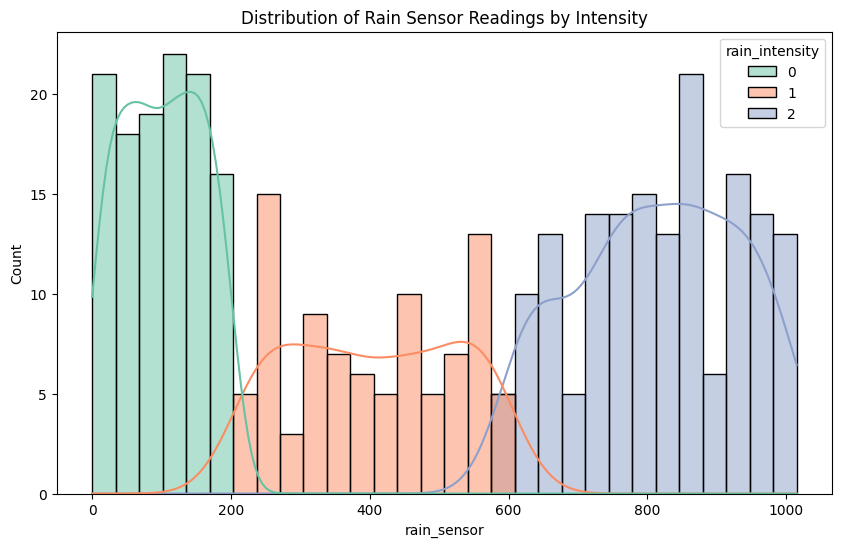

In [16]:
# Quick Visualization

import seaborn as sns

# Distribution of Rain Sensor Readings by Intensity

plt.figure(figsize=(10,6))
sns.histplot(data, x="rain_sensor", hue="rain_intensity", bins=30, palette="Set2", kde=True)
plt.title("Distribution of Rain Sensor Readings by Intensity")
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_23288\57552857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rain_intensity", y="humidity", data=data, palette="coolwarm")


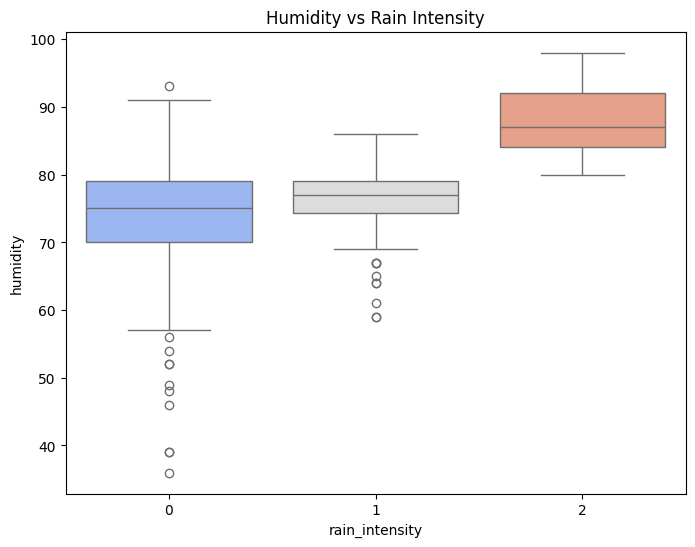

In [17]:
# Humidity vs Rain Intensity

plt.figure(figsize=(8,6))
sns.boxplot(x="rain_intensity", y="humidity", data=data, palette="coolwarm")
plt.title("Humidity vs Rain Intensity")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_23288\1334540655.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rain_intensity", y="cloud", data=data, palette="magma")


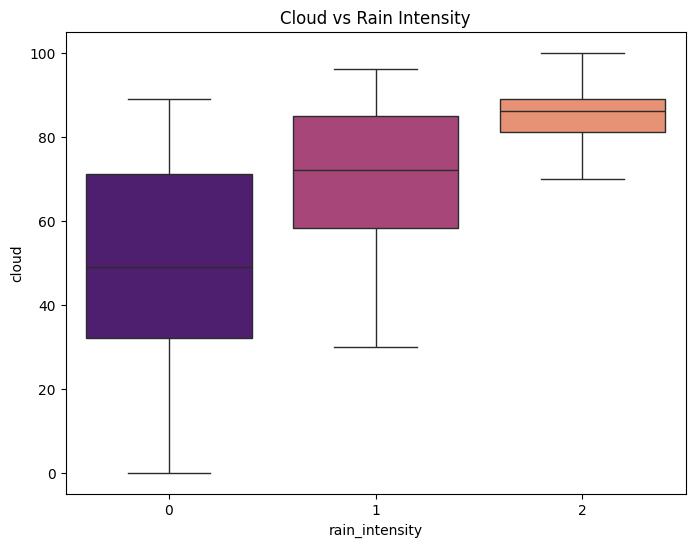

In [18]:
# Cloud vs Rain Intensity

plt.figure(figsize=(8,6))
sns.boxplot(x="rain_intensity", y="cloud", data=data, palette="magma")
plt.title("Cloud vs Rain Intensity")
plt.show()

In [ ]:
data.columns = [c.strip().lower().replace("temparature", "temperature").replace(" ", "_") for c in data.columns]

# Check the cleaned names
print(data.columns.tolist())

['day', 'pressure', 'maxtemp', 'temperature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed']


In [ ]:
# =========================
# Rain Prediction Simulation
# =========================

# Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Load your preprocessed data (from earlier steps)
data = pd.read_csv("Rainfall.csv")

# Clean columns (strip spaces, lowercase, fix typo)
def clean_col(c):
    c2 = c.strip().lower().replace(" ", "_")
    c2 = c2.replace("temparature", "temperature")
    return c2

data.columns = [clean_col(c) for c in data.columns]

# Fill numeric columns with mean
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Features and target
X = data.drop(columns=['day','rainintensity'])  # Drop 'day' and target
y = data['rainintensity']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="rain_nn_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Function to simulate RainSensor input and predict
def simulate_rain_sensor(sensor_value, scaled=True):
    # Prepare dummy row with all features except target
    row = X.iloc[0].copy()  # just copy structure
    row['rainsensor'] = sensor_value  # only changing RainSensor
    
    # Scale
    if scaled:
        row_scaled = scaler.transform([row.values.astype(np.float32)])
    else:
        row_scaled = np.array([row.values], dtype=np.float32)
    
    # Run TFLite inference
    interpreter.set_tensor(input_details[0]['index'], row_scaled)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_class = np.argmax(output)
    return pred_class

# =========================
# Test Simulation
# =========================
test_values = [100, 400, 800]  # Example RainSensor values

for val in test_values:
    pred = simulate_rain_sensor(val)
    print(f"RainSensor={val} → Predicted RainIntensity={pred}")
